In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Gunjan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_csv('../data/clustered_data.csv')

print(f' Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n Target variable: time_in_hospital')
print(df['time_in_hospital'].describe().round(2))
df.head()

 Loaded dataset: 101,766 rows × 45 columns

 Target variable: time_in_hospital
count    101766.00
mean          4.40
std           2.99
min           1.00
25%           2.00
50%           4.00
75%           6.00
max          14.00
Name: time_in_hospital, dtype: float64


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30,cluster
0,2,0,0,6,25,1,1,7,41,0,...,1,1,0,0,0,0,1,0,0,2
1,2,0,1,1,1,7,3,7,59,0,...,3,1,0,0,0,0,0,1,0,2
2,0,0,2,1,1,7,2,7,11,5,...,1,1,0,0,0,0,1,1,0,2
3,2,1,3,1,1,7,2,7,44,1,...,3,1,0,0,0,0,0,1,0,2
4,2,1,4,1,1,7,1,7,51,0,...,2,1,0,0,0,0,0,1,0,2


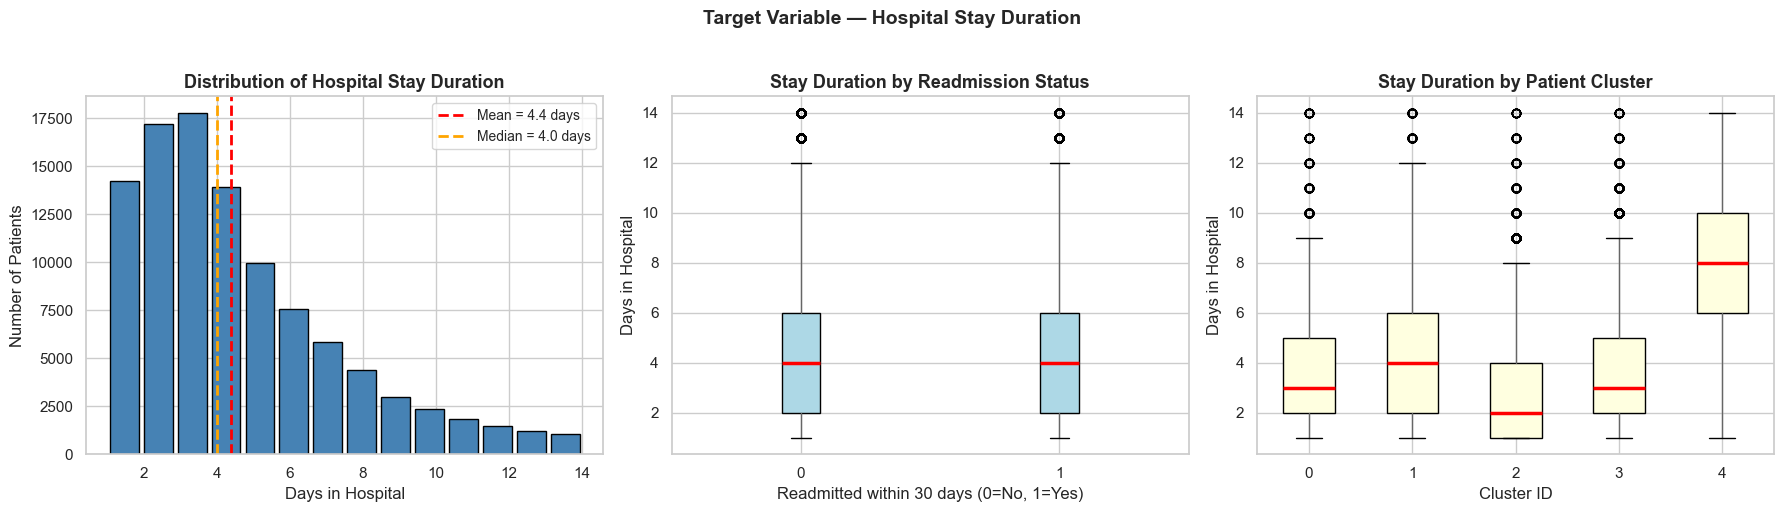

💾 Saved: ../outputImg/reg_chart1_target_distribution.png


In [4]:
# ----- CHART 1: Target Variable Distribution -----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['time_in_hospital'], bins=14, color='steelblue',
             edgecolor='black', rwidth=0.85)
axes[0].axvline(df['time_in_hospital'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean = {df["time_in_hospital"].mean():.1f} days')
axes[0].axvline(df['time_in_hospital'].median(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Median = {df["time_in_hospital"].median():.1f} days')
axes[0].set_title('Distribution of Hospital Stay Duration',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days in Hospital')
axes[0].set_ylabel('Number of Patients')
axes[0].legend(fontsize=10)

# Box plot by readmission
df.boxplot(column='time_in_hospital', by='readmitted_30', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2.5))
axes[1].set_title('Stay Duration by Readmission Status',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Readmitted within 30 days (0=No, 1=Yes)')
axes[1].set_ylabel('Days in Hospital')
plt.suptitle('')

# Box plot by cluster
if 'cluster' in df.columns:
    df.boxplot(column='time_in_hospital', by='cluster', ax=axes[2],
               patch_artist=True,
               boxprops=dict(facecolor='lightyellow'),
               medianprops=dict(color='red', linewidth=2.5))
    axes[2].set_title('Stay Duration by Patient Cluster',
                      fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Cluster ID')
    axes[2].set_ylabel('Days in Hospital')
    plt.suptitle('')

plt.suptitle('Target Variable — Hospital Stay Duration',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputImg/reg_chart1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../outputImg/reg_chart1_target_distribution.png')

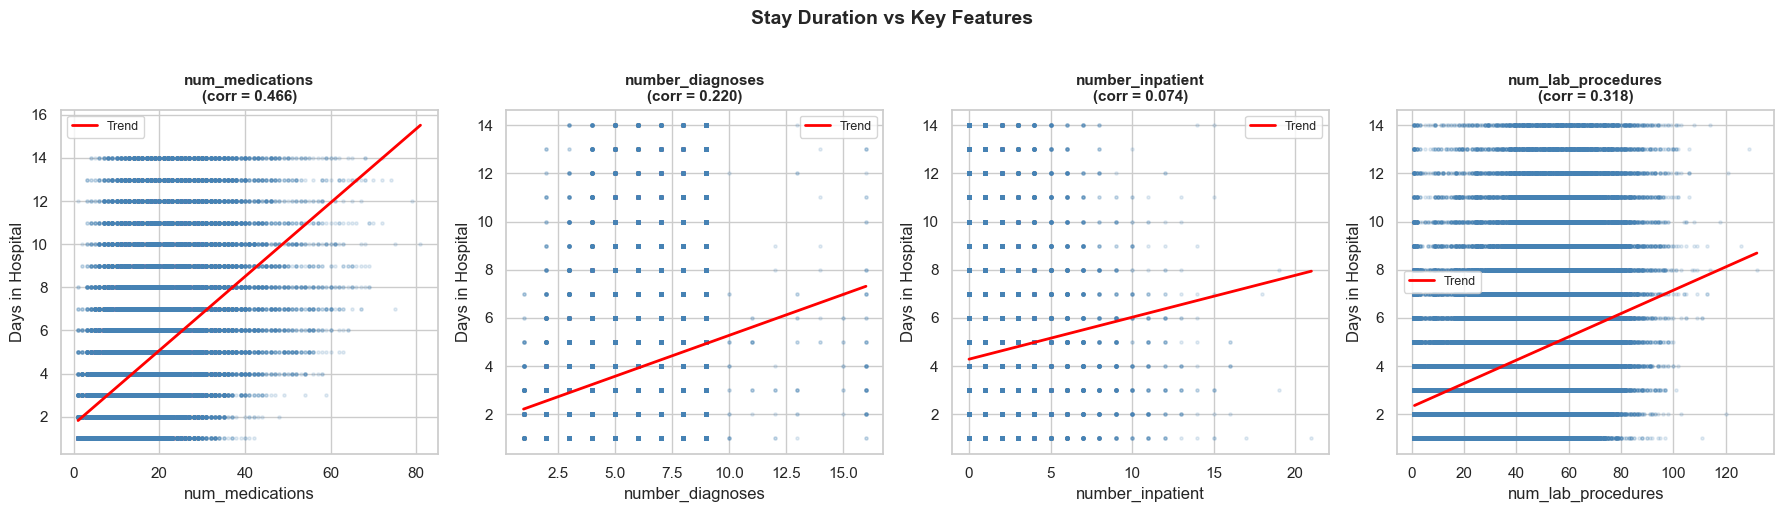

💾 Saved: ../outputImg/reg_chart2_feature_vs_target.png


In [5]:
# ----- CHART 2: Stay Duration vs Key Features -----
key_features = ['num_medications', 'number_diagnoses',
                'number_inpatient', 'num_lab_procedures']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 5))
if len(key_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, key_features):
    ax.scatter(df[feat], df['time_in_hospital'],
               alpha=0.15, s=5, color='steelblue')
    # Add trend line
    z = np.polyfit(df[feat], df['time_in_hospital'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
    corr = df[feat].corr(df['time_in_hospital'])
    ax.set_title(f'{feat}\n(corr = {corr:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Days in Hospital')
    ax.legend(fontsize=9)

plt.suptitle('Stay Duration vs Key Features', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputImg/reg_chart2_feature_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../outputImg/reg_chart2_feature_vs_target.png')

In [6]:
drop_cols = ['time_in_hospital', 'readmitted_30']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['time_in_hospital']

print(f' Features (X): {X.shape}')
print(f' Target  (y): {y.shape}')
print(f'\n Target stats:')
print(f'   Min:    {y.min()} days')
print(f'   Max:    {y.max()} days')
print(f'   Mean:   {y.mean():.2f} days')
print(f'   Median: {y.median():.1f} days')
print(f'   Std:    {y.std():.2f} days')

 Features (X): (101766, 43)
 Target  (y): (101766,)

 Target stats:
   Min:    1 days
   Max:    14 days
   Mean:   4.40 days
   Median: 4.0 days
   Std:    2.99 days


In [7]:
# Train / Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for Linear Regression, Ridge, Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, '../models/regression_scaler.pkl')

print(f' Train set: {X_train.shape[0]:,} samples')
print(f' Test set:  {X_test.shape[0]:,} samples')
print(f' Regression scaler saved to ../models/regression_scaler.pkl')

 Train set: 81,412 samples
 Test set:  20,354 samples
 Regression scaler saved to ../models/regression_scaler.pkl


In [8]:
# Define all models
models = {
    'Linear Regression':         LinearRegression(),
    'Ridge Regression':          Ridge(alpha=1.0),
    'Lasso Regression':          Lasso(alpha=0.1, max_iter=5000),
    'Decision Tree':             DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':             RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':         GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':                   XGBRegressor(n_estimators=100, random_state=42,
                                               verbosity=0, eval_metric='rmse')
}

results = []
trained_models = {}

print(' Training regression models...\n')
for name, model in models.items():
    print(f'   Training {name}...', end=' ')

    # Use scaled data for linear models, raw for tree-based
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Clip negative predictions to 1 (minimum 1 day stay)
    y_pred = np.clip(y_pred, 1, 14)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results.append({
        'Model':    name,
        'RMSE':     round(rmse, 4),
        'MAE':      round(mae,  4),
        'R²':       round(r2,   4),
        'MAPE (%)': round(mape, 2)
    })
    trained_models[name] = (model, y_pred)
    print(f'Done! | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}')

print('\n All models trained!')

 Training regression models...

   Training Linear Regression... Done! | RMSE: 2.371 | MAE: 1.821 | R²: 0.354
   Training Ridge Regression... Done! | RMSE: 2.371 | MAE: 1.821 | R²: 0.354
   Training Lasso Regression... Done! | RMSE: 2.398 | MAE: 1.845 | R²: 0.339
   Training Decision Tree... Done! | RMSE: 2.097 | MAE: 1.592 | R²: 0.495
   Training Random Forest... Done! | RMSE: 1.994 | MAE: 1.520 | R²: 0.543
   Training Gradient Boosting... Done! | RMSE: 2.047 | MAE: 1.567 | R²: 0.519
   Training XGBoost... Done! | RMSE: 1.958 | MAE: 1.484 | R²: 0.560

 All models trained!


In [9]:
results_df = pd.DataFrame(results).sort_values('RMSE', ascending=True)

print(' Model Comparison Table (sorted by RMSE — lower is better):')
display(results_df.style
    .highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='#d4f5d4')
    .highlight_max(subset=['R²'], color='#d4f5d4')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}',
             'R²': '{:.4f}', 'MAPE (%)': '{:.2f}'})
    .set_properties(**{'font-size': '13px'})
)

 Model Comparison Table (sorted by RMSE — lower is better):


,Model,RMSE,MAE,R²,MAPE (%)
6,XGBoost,1.9576,1.4843,0.5597,50.51
4,Random Forest,1.9945,1.5195,0.5430,53.03
5,Gradient Boosting,2.0467,1.5665,0.5187,55.05
3,Decision Tree,2.0974,1.5921,0.4946,55.50
0,Linear Regression,2.3711,1.8208,0.3541,64.30
1,Ridge Regression,2.3711,1.8208,0.3541,64.30
2,Lasso Regression,2.3980,1.8453,0.3393,66.35


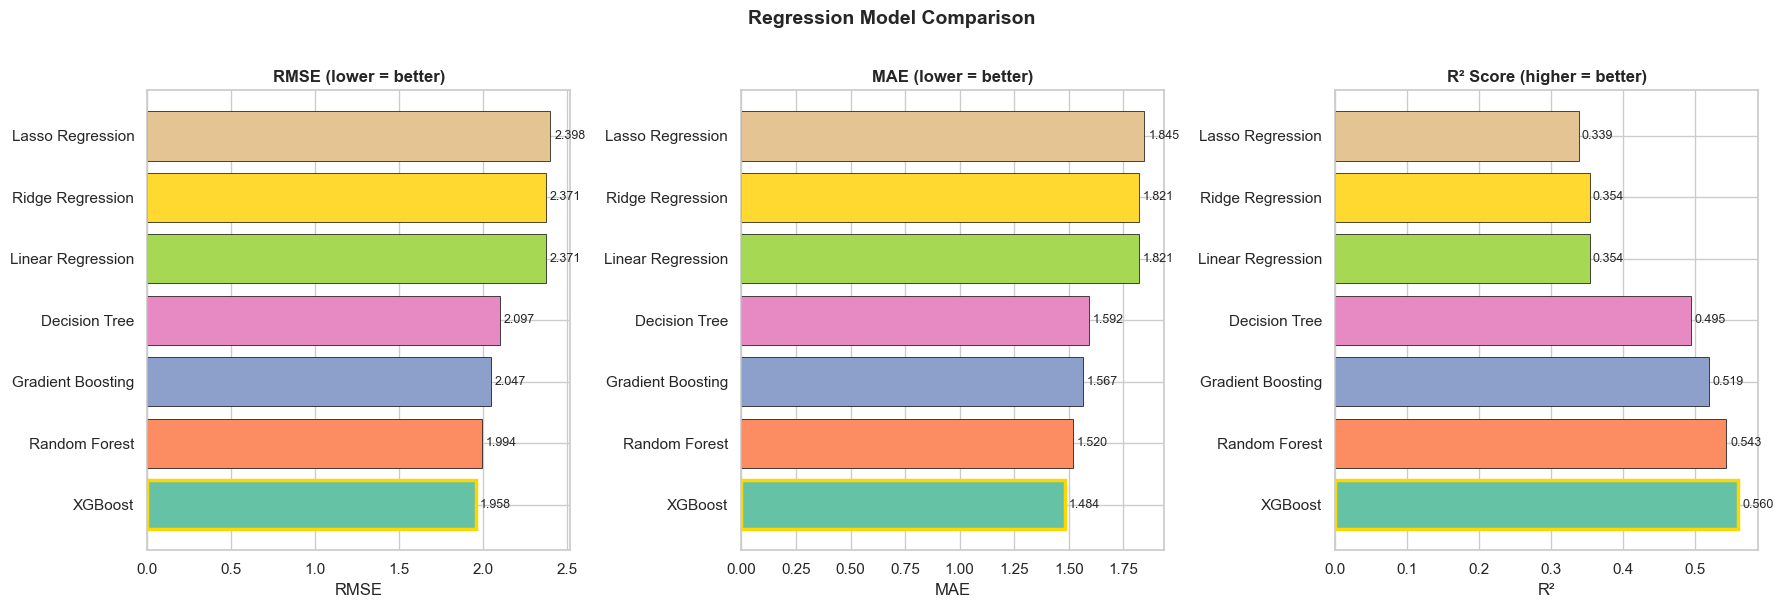

 Saved: ../outputImg/reg_chart3_model_comparison.png


In [10]:
# ----- CHART 3: Model Comparison Bar Chart -----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = sns.color_palette('Set2', len(results_df))

metrics_to_plot = [
    ('RMSE',     'RMSE (lower = better)',  True),
    ('MAE',      'MAE (lower = better)',   True),
    ('R²',       'R² Score (higher = better)', False)
]

for ax, (metric, title, lower_better) in zip(axes, metrics_to_plot):
    sorted_df = results_df.sort_values(metric, ascending=lower_better)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    # Highlight best bar
    best_bar = bars[0]
    best_bar.set_edgecolor('gold')
    best_bar.set_linewidth(2.5)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + w*0.01, bar.get_y() + bar.get_height()/2,
                f'{w:.3f}', va='center', fontsize=9)

plt.suptitle('Regression Model Comparison', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/reg_chart3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/reg_chart3_model_comparison.png')

In [11]:
# Select best model by RMSE
best_model_name = results_df.iloc[0]['Model']
best_model, best_y_pred = trained_models[best_model_name]

print(f' Best Model: {best_model_name}')
print(f'   RMSE:     {results_df.iloc[0]["RMSE"]:.4f} days')
print(f'   MAE:      {results_df.iloc[0]["MAE"]:.4f} days')
print(f'   R²:       {results_df.iloc[0]["R²"]:.4f}')
print(f'   MAPE:     {results_df.iloc[0]["MAPE (%)"]:.2f}%')
print(f'\n Interpretation:')
print(f'   On average, predictions are off by {results_df.iloc[0]["MAE"]:.2f} days')
print(f'   The model explains {results_df.iloc[0]["R²"]*100:.1f}% of variance in stay duration')

 Best Model: XGBoost
   RMSE:     1.9576 days
   MAE:      1.4843 days
   R²:       0.5597
   MAPE:     50.51%

 Interpretation:
   On average, predictions are off by 1.48 days
   The model explains 56.0% of variance in stay duration


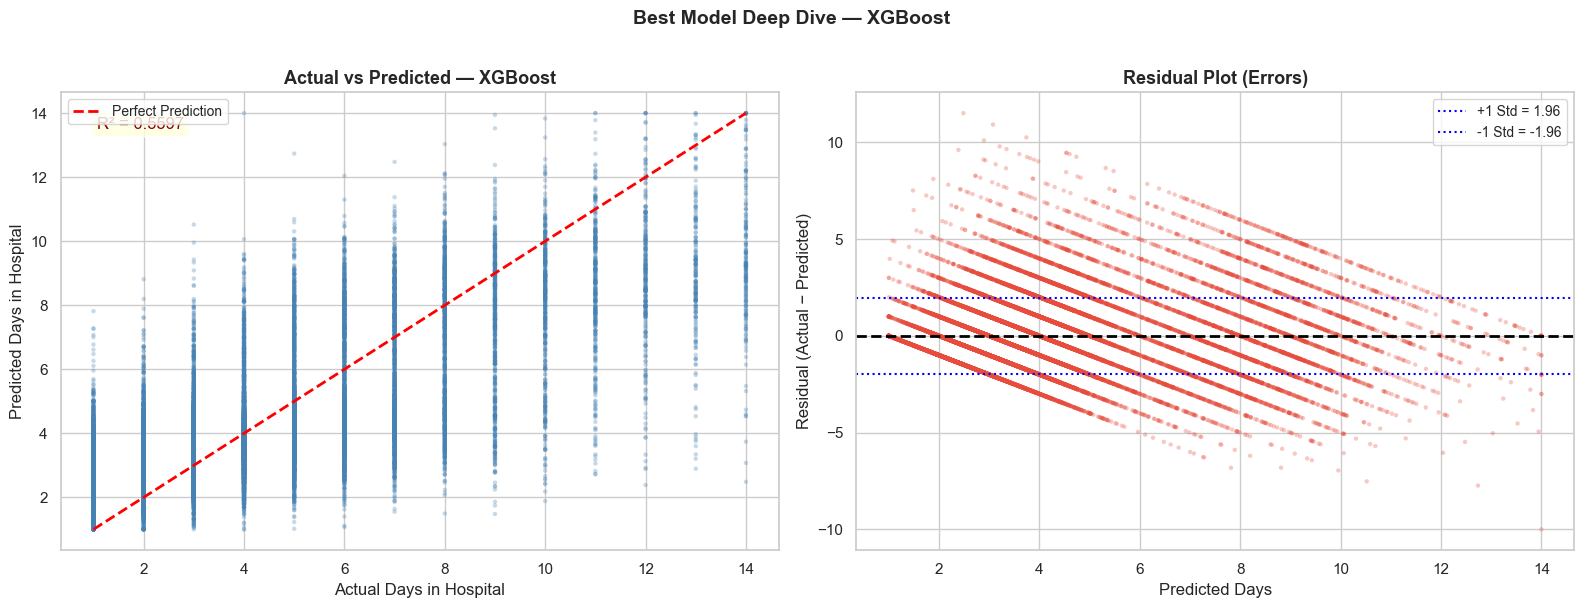

💾 Saved: ../outputImg/reg_chart4_actual_vs_predicted.png


In [12]:
# ----- CHART 4: Actual vs Predicted Scatter -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: actual vs predicted
axes[0].scatter(y_test, best_y_pred, alpha=0.3, s=10,
                color='steelblue', edgecolors='none')
min_val = min(y_test.min(), best_y_pred.min())
max_val = max(y_test.max(), best_y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted — {best_model_name}',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Days in Hospital')
axes[0].set_ylabel('Predicted Days in Hospital')
axes[0].legend(fontsize=10)

# Add R² annotation
r2 = results_df.iloc[0]['R²']
axes[0].annotate(f'R² = {r2:.4f}',
                 xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# Residual plot
residuals = y_test.values - best_y_pred
axes[1].scatter(best_y_pred, residuals, alpha=0.3, s=10,
                color='#e74c3c', edgecolors='none')
axes[1].axhline(0, color='black', linestyle='--', linewidth=2)
axes[1].axhline(residuals.std(), color='blue', linestyle=':', linewidth=1.5,
                label=f'+1 Std = {residuals.std():.2f}')
axes[1].axhline(-residuals.std(), color='blue', linestyle=':', linewidth=1.5,
                label=f'-1 Std = {-residuals.std():.2f}')
axes[1].set_title('Residual Plot (Errors)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Days')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].legend(fontsize=10)

plt.suptitle(f'Best Model Deep Dive — {best_model_name}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/reg_chart4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../outputImg/reg_chart4_actual_vs_predicted.png')

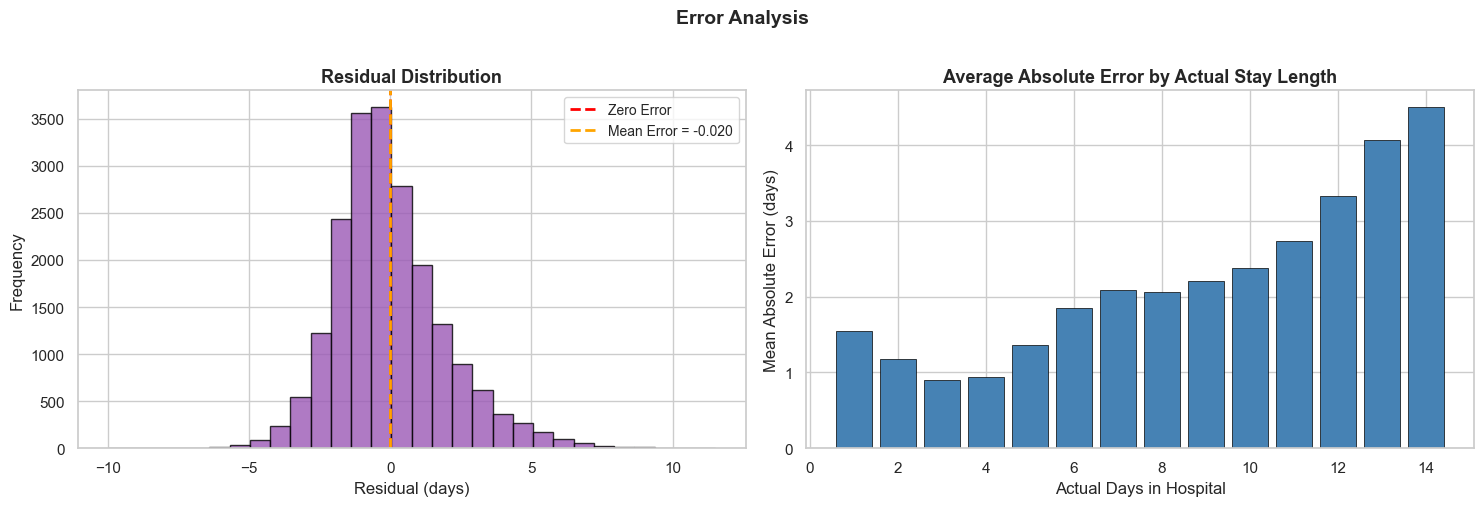

💾 Saved: models/reg_chart5_residual_analysis.png


In [13]:
# ----- CHART 5: Residual Distribution -----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=30, color='#9b59b6',
             edgecolor='black', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean Error = {residuals.mean():.3f}')
axes[0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (days)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=10)

# Error breakdown by actual stay length
error_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': best_y_pred,
    'abs_error': np.abs(residuals)
})
avg_error_by_stay = error_df.groupby('actual')['abs_error'].mean()

axes[1].bar(avg_error_by_stay.index, avg_error_by_stay.values,
            color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Absolute Error by Actual Stay Length',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Days in Hospital')
axes[1].set_ylabel('Mean Absolute Error (days)')

plt.suptitle('Error Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/reg_chart5_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: models/reg_chart5_residual_analysis.png')

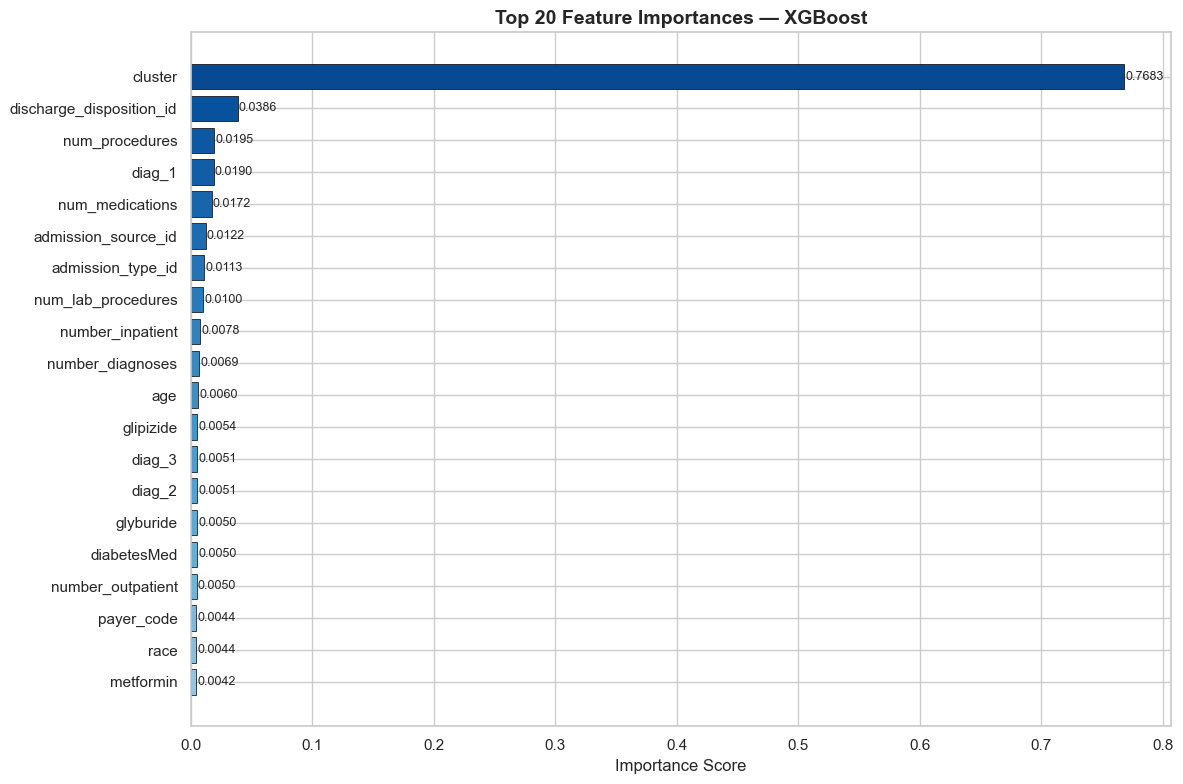

 Saved: ../outputImg/reg_chart6_feature_importance.png


In [14]:
# ----- CHART 6: Feature Importance -----
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature':    X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    import matplotlib.cm as cm
    colors_imp = cm.Blues(np.linspace(0.4, 0.9, len(importance_df)))
    bars = ax.barh(importance_df['Feature'][::-1],
                   importance_df['Importance'][::-1],
                   color=colors_imp, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('../outputImg/reg_chart6_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: ../outputImg/reg_chart6_feature_importance.png')

elif hasattr(best_model, 'coef_'):
    # For linear models — show coefficients
    coef_df = pd.DataFrame({
        'Feature':     X.columns,
        'Coefficient': best_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient'][::-1]]
    ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
            color=colors_coef, edgecolor='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1.5)
    ax.set_title(f'Top 20 Feature Coefficients — {best_model_name}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Coefficient Value')

    plt.tight_layout()
    plt.savefig('../outputImg/reg_chart6_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: ../outputImg/reg_chart6_feature_importance.png')

In [15]:
# Proper K-fold cross validation on training data
print(f' Running 5-Fold Cross Validation on {best_model_name}...\n')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = cross_val_score(
    best_model, X_train, y_train,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
cv_r2 = cross_val_score(
    best_model, X_train, y_train,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

cv_rmse_pos = -cv_rmse  # convert negative to positive

print(f'  CV RMSE Scores: {[round(s, 4) for s in cv_rmse_pos]}')
print(f'  Mean RMSE:      {cv_rmse_pos.mean():.4f} ± {cv_rmse_pos.std():.4f}')
print(f'\n  CV R² Scores:   {[round(s, 4) for s in cv_r2]}')
print(f'  Mean R²:        {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

if cv_rmse_pos.std() < 0.1:
    print('\n Model is stable — low variance across folds')
else:
    print('\n  Some variance across folds — consider tuning hyperparameters')

 Running 5-Fold Cross Validation on XGBoost...

  CV RMSE Scores: [1.9682, 1.9826, 1.949, 1.9619, 1.9789]
  Mean RMSE:      1.9681 ± 0.0121

  CV R² Scores:   [0.5601, 0.5627, 0.5734, 0.5736, 0.5687]
  Mean R²:        0.5677 ± 0.0055

 Model is stable — low variance across folds


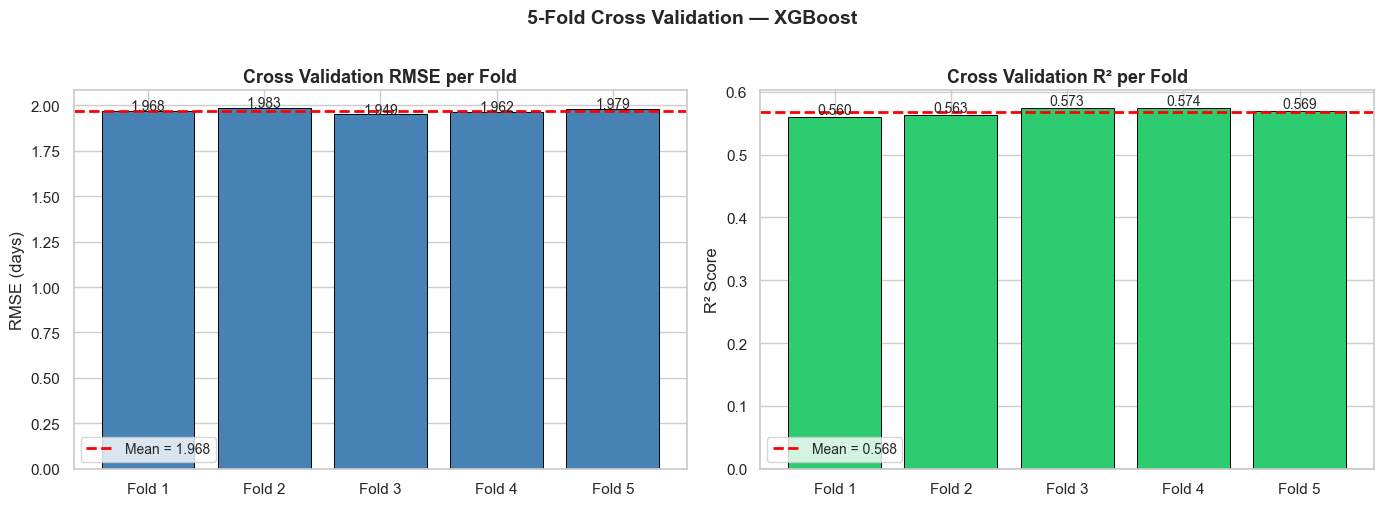

💾 Saved: ../outputImg//reg_chart7_cross_validation.png


In [16]:
# ----- CHART 7: Cross Validation Results -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds = [f'Fold {i+1}' for i in range(5)]

# RMSE per fold
axes[0].bar(folds, cv_rmse_pos, color='steelblue',
            edgecolor='black', linewidth=0.7)
axes[0].axhline(cv_rmse_pos.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean = {cv_rmse_pos.mean():.3f}')
axes[0].set_title('Cross Validation RMSE per Fold',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('RMSE (days)')
axes[0].legend(fontsize=10)
for i, v in enumerate(cv_rmse_pos):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# R² per fold
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in cv_r2]
axes[1].bar(folds, cv_r2, color=bar_colors,
            edgecolor='black', linewidth=0.7)
axes[1].axhline(cv_r2.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean = {cv_r2.mean():.3f}')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Cross Validation R² per Fold',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].legend(fontsize=10)
for i, v in enumerate(cv_r2):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle(f'5-Fold Cross Validation — {best_model_name}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg//reg_chart7_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../outputImg//reg_chart7_cross_validation.png')

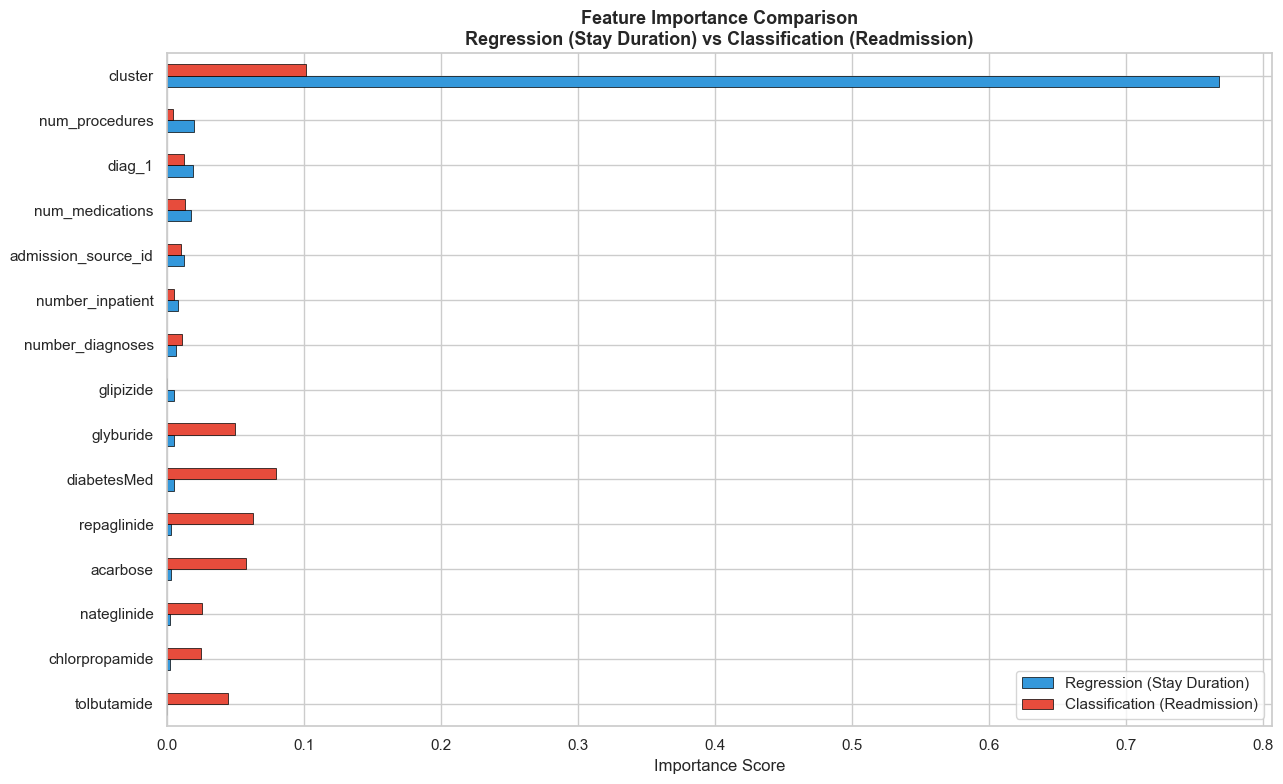

💾 Saved: ../outputImg/reg_chart8_importance_comparison.png


In [17]:
# Compare which features matter for STAYING LONG vs being READMITTED
# Load classification feature importance if it exists
try:
    clf_model = joblib.load('../models/classification_model.pkl')
    top_clf_features = joblib.load('../models/top_features.pkl')

    if hasattr(best_model, 'feature_importances_') and hasattr(clf_model, 'feature_importances_'):
        reg_imp = pd.Series(best_model.feature_importances_, index=X.columns)
        clf_imp = pd.Series(clf_model.feature_importances_, index=X.columns)

        # Get top 15 features from either model
        top_features_union = list(set(
            reg_imp.nlargest(15).index.tolist() +
            clf_imp.nlargest(15).index.tolist()
        ))[:15]

        compare_df = pd.DataFrame({
            'Regression (Stay Duration)': reg_imp[top_features_union],
            'Classification (Readmission)': clf_imp[top_features_union]
        }).sort_values('Regression (Stay Duration)', ascending=True)

        fig, ax = plt.subplots(figsize=(13, 8))
        compare_df.plot(kind='barh', ax=ax,
                        color=['#3498db', '#e74c3c'],
                        edgecolor='black', linewidth=0.5)
        ax.set_title('Feature Importance Comparison\nRegression (Stay Duration) vs Classification (Readmission)',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Importance Score')
        ax.legend(fontsize=11)

        plt.tight_layout()
        plt.savefig('../outputImg/reg_chart8_importance_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('💾 Saved: ../outputImg/reg_chart8_importance_comparison.png')
    else:
        print('ℹ  Feature importance comparison requires tree-based models for both tasks')
except FileNotFoundError:
    print('  ../models/classification_model.pkl not found — skipping comparison chart')
    print('   (Run Notebook 2 first, then re-run this cell)')

In [18]:
print('=' * 65)
print(' REGRESSION — FINAL SUMMARY FOR PROJECT REPORT')
print('=' * 65)
print(f'\n Task: Predict hospital length of stay (days)')
print(f' Dataset: {len(df):,} patients')
print(f'   Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\n All Models Performance:')
print(results_df.to_string(index=False))
print(f'\n Best Model: {best_model_name}')
print(f'   RMSE:  {results_df.iloc[0]["RMSE"]:.4f} days')
print(f'   MAE:   {results_df.iloc[0]["MAE"]:.4f} days')
print(f'   R²:    {results_df.iloc[0]["R²"]:.4f}')
print(f'   MAPE:  {results_df.iloc[0]["MAPE (%)"]:.2f}%')
print(f'\n Cross Validation (5-Fold):')
print(f'   Mean RMSE: {cv_rmse_pos.mean():.4f} ± {cv_rmse_pos.std():.4f}')
print(f'   Mean R²:   {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'\n💡 Interpretation:')
print(f'   Predictions are off by ~{results_df.iloc[0]["MAE"]:.1f} days on average')
print(f'   The model explains {results_df.iloc[0]["R²"]*100:.1f}% of variance in stay duration')
print('\n' + '=' * 65)

 REGRESSION — FINAL SUMMARY FOR PROJECT REPORT

 Task: Predict hospital length of stay (days)
 Dataset: 101,766 patients
   Train: 81,412 | Test: 20,354

 All Models Performance:
            Model   RMSE    MAE     R²  MAPE (%)
          XGBoost 1.9576 1.4843 0.5597     50.51
    Random Forest 1.9945 1.5195 0.5430     53.03
Gradient Boosting 2.0467 1.5665 0.5187     55.05
    Decision Tree 2.0974 1.5921 0.4946     55.50
Linear Regression 2.3711 1.8208 0.3541     64.30
 Ridge Regression 2.3711 1.8208 0.3541     64.30
 Lasso Regression 2.3980 1.8453 0.3393     66.35

 Best Model: XGBoost
   RMSE:  1.9576 days
   MAE:   1.4843 days
   R²:    0.5597
   MAPE:  50.51%

 Cross Validation (5-Fold):
   Mean RMSE: 1.9681 ± 0.0121
   Mean R²:   0.5677 ± 0.0055

💡 Interpretation:
   Predictions are off by ~1.5 days on average
   The model explains 56.0% of variance in stay duration



In [19]:
joblib.dump(best_model, '../models/regression_model.pkl')

# Save regression feature column names (Flask API needs these)
joblib.dump(list(X.columns), '../models/regression_feature_columns.pkl')

# Save results table
results_df.to_csv('../data/regression_results.csv', index=False)